In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel("Workforce_Analysis.xlsx")

print(df.columns.tolist(), "\n")
print(df.head())

['ID', 'Service or Profession', 'Provider Found', 'Demand Level', 'Competition Level', 'Rank', '% Formal Companies', '% App or Platform', '% Directory or Informal', 'Supply Status'] 

   ID Service or Profession  Provider Found Demand Level Competition Level  \
0   1         Deep Cleaning              14         High              High   
1   2           Garden Care              11          Low              High   
2   3        Masonry Repair               6         High            Medium   
3   4       Plumbing Repair              20         High              High   
4   5     Electrical Repair              19         High              High   

   Rank  % Formal Companies  % App or Platform  % Directory or Informal  \
0     4            0.500000           0.428571                 0.071429   
1     6            0.727273           0.181818                 0.090909   
2    23            0.500000           0.500000                 0.000000   
3     1            0.450000           0.500000 

In [3]:
# Quick check on data shape
print(f"Total services: {len(df)}\n")
print(df["Supply Status"].value_counts(), "\n")
print(df["Demand Level"].value_counts(), "\n")
print(df["Competition Level"].value_counts(), "\n")

Total services: 40

Supply Status
Sufficient     19
Limited        16
Well-served     5
Name: count, dtype: int64 

Demand Level
High      17
Medium    13
Low       10
Name: count, dtype: int64 

Competition Level
High      17
Low       12
Medium    11
Name: count, dtype: int64 



### Chart 1 - Number of Providers Found per Service Category

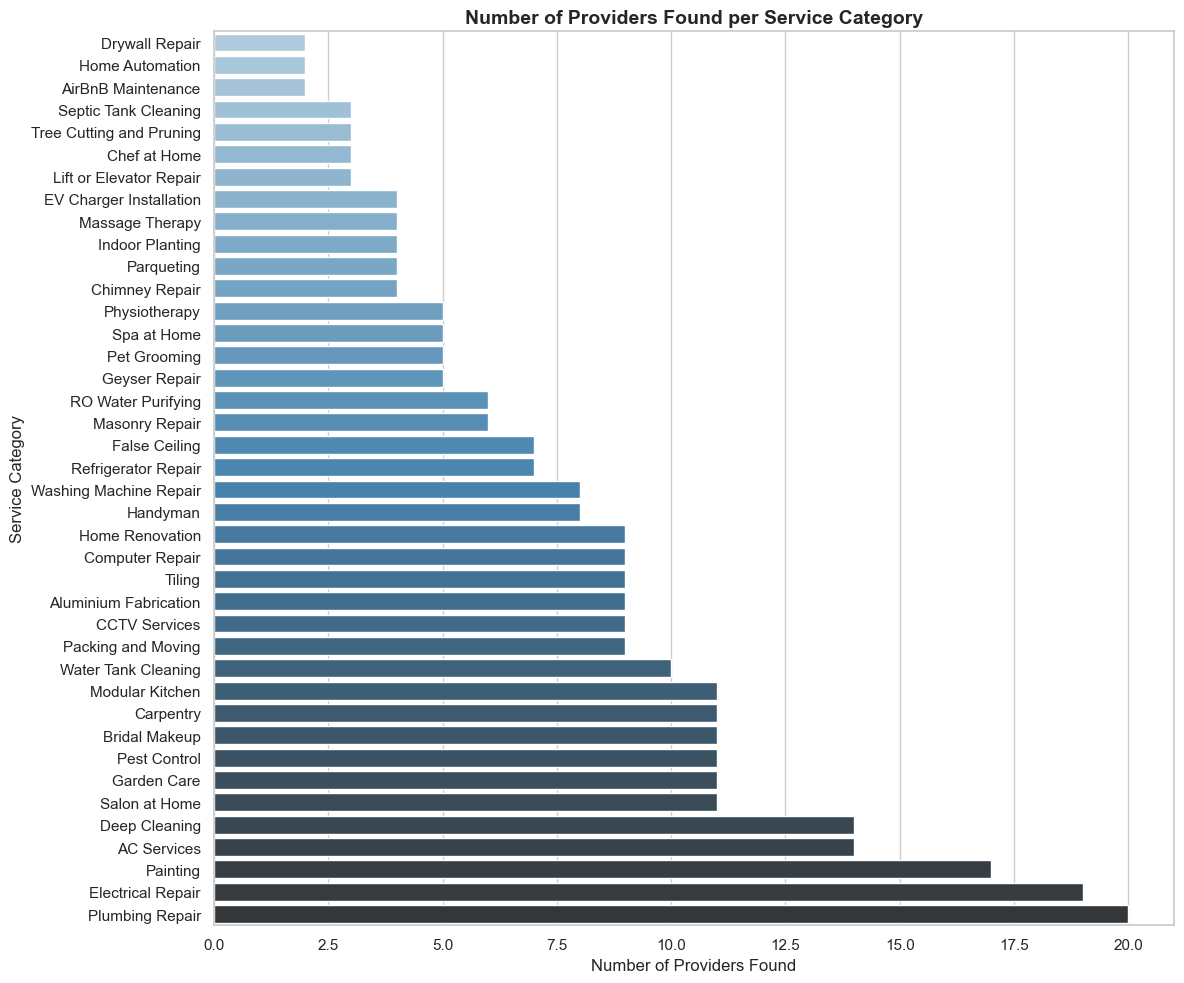

In [4]:
sns.set_theme(style="whitegrid")

df_sorted = df.sort_values("Provider Found", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=df_sorted, x="Provider Found", y="Service or Profession", hue="Service or Profession", palette="Blues_d", legend=False)

plt.title("Number of Providers Found per Service Category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Providers Found", fontsize=12)
plt.ylabel("Service Category", fontsize=12)

plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 - Formal vs App vs Directory Percentage across all Services

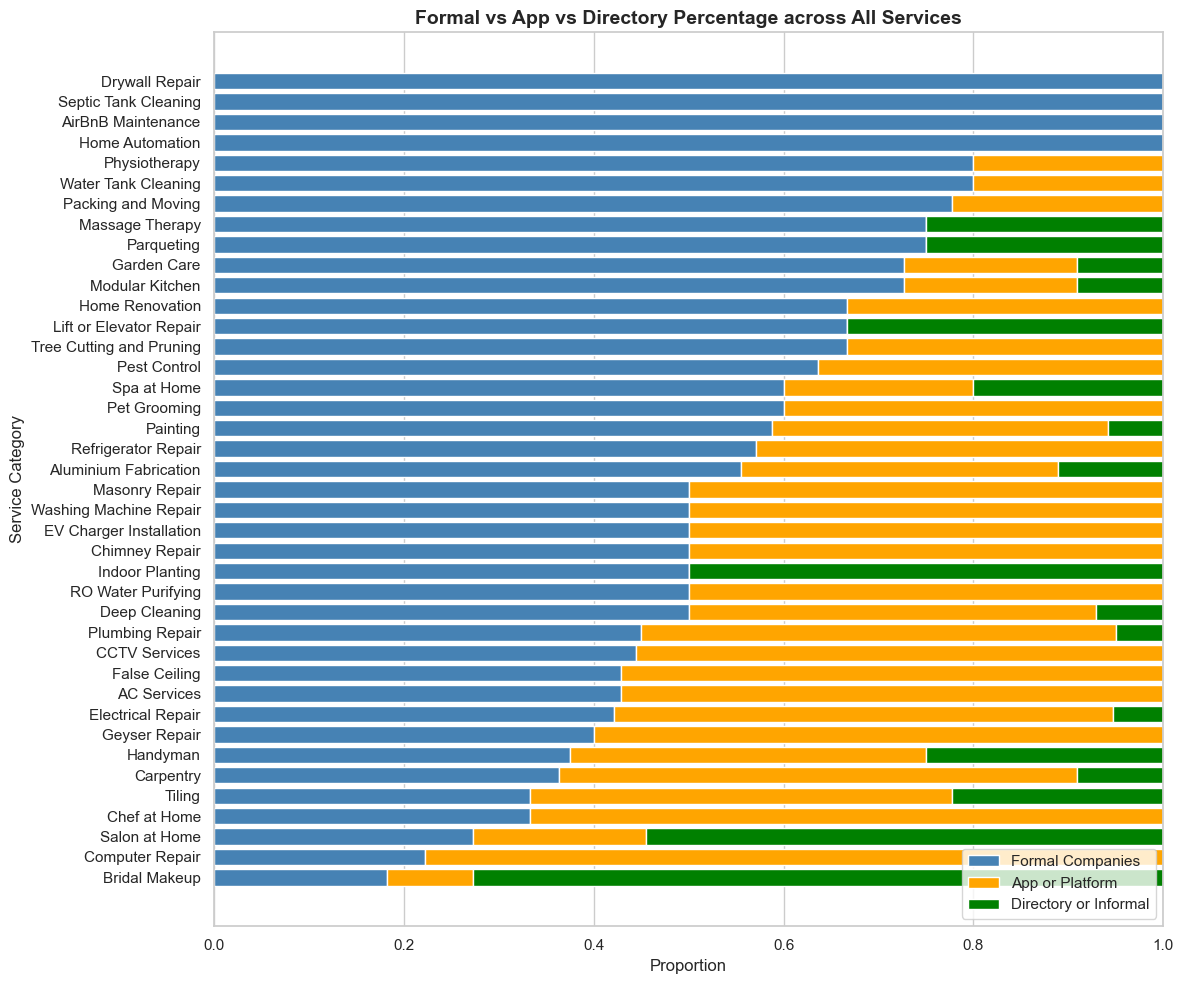

In [5]:
sns.set_theme(style="whitegrid")

df_sorted = df.sort_values("% Formal Companies", ascending=True)

plt.figure(figsize=(12, 10))

plt.barh(df_sorted["Service or Profession"], df_sorted["% Formal Companies"], label="Formal Companies", color="steelblue")
plt.barh(df_sorted["Service or Profession"], df_sorted["% App or Platform"], left=df_sorted["% Formal Companies"], label="App or Platform", color="orange")
plt.barh(df_sorted["Service or Profession"], df_sorted["% Directory or Informal"], left=df_sorted["% Formal Companies"] + df_sorted["% App or Platform"], label="Directory or Informal", color="green")

plt.title("Formal vs App vs Directory Percentage across All Services", fontsize=14, fontweight="bold")
plt.xlabel("Proportion", fontsize=12)
plt.ylabel("Service Category", fontsize=12)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 - Demand Level Distribution

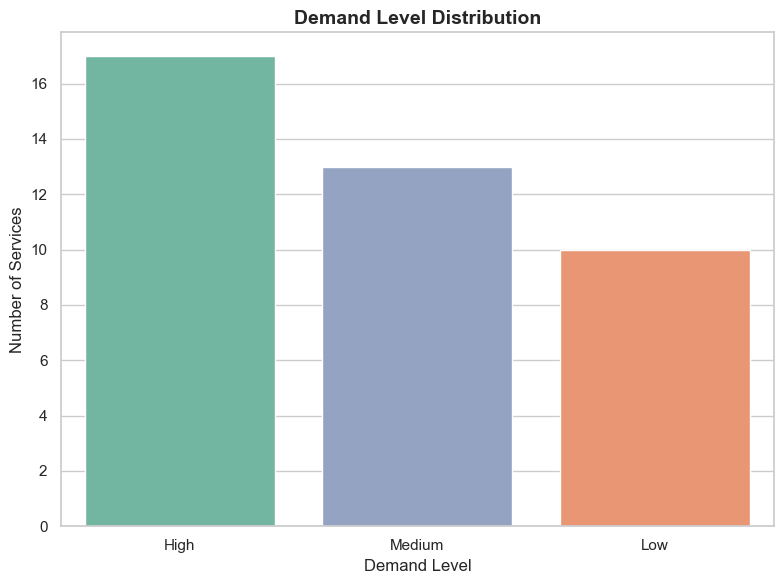

In [6]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Demand Level", hue="Demand Level", palette="Set2", legend=False, order=["High", "Medium", "Low"])

plt.title("Demand Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Demand Level", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)

plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 - Supply Status Distribution

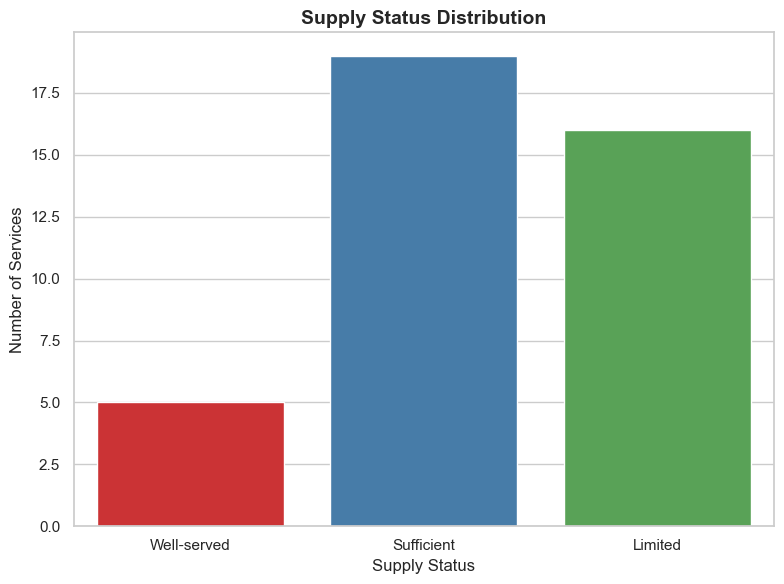

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Supply Status", hue="Supply Status", palette="Set1", legend=False, order=["Well-served", "Sufficient", "Limited"])

plt.title("Supply Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Supply Status", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)

plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 5 - Competition Level Distribution

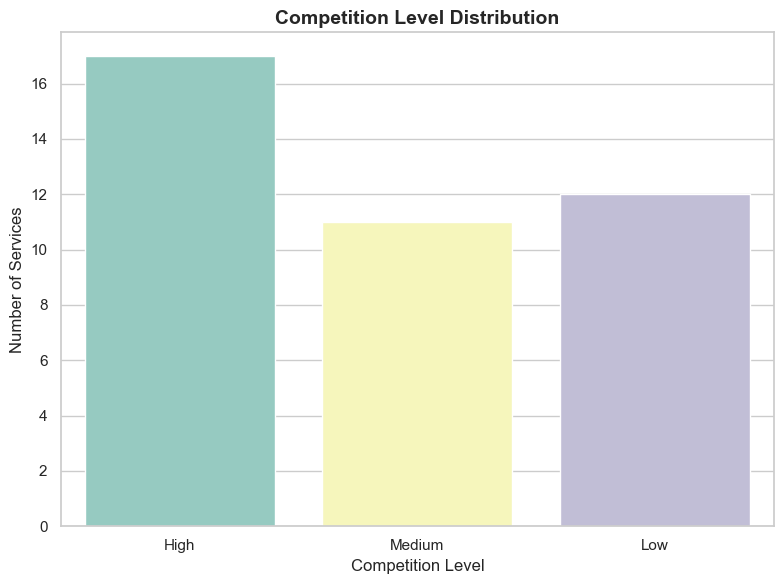

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Competition Level", hue="Competition Level", palette="Set3", legend=False, order=["High", "Medium", "Low"])

plt.title("Competition Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Competition Level", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)

plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 6 - Demand Level vs Competition Level Cross Tabulation

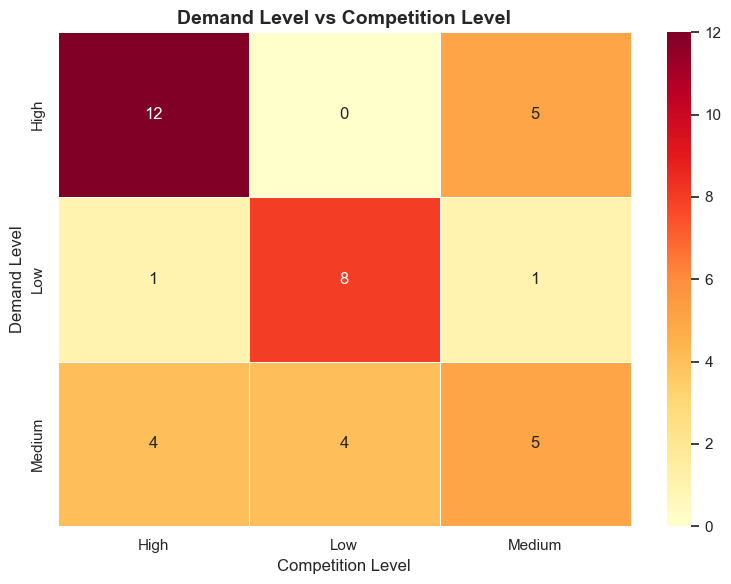

In [9]:
sns.set_theme(style="whitegrid")

cross_tab = pd.crosstab(df["Demand Level"], df["Competition Level"])

plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)

plt.title("Demand Level vs Competition Level", fontsize=14, fontweight="bold")
plt.xlabel("Competition Level", fontsize=12)
plt.ylabel("Demand Level", fontsize=12)

plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 7 - Providers Found vs Rank

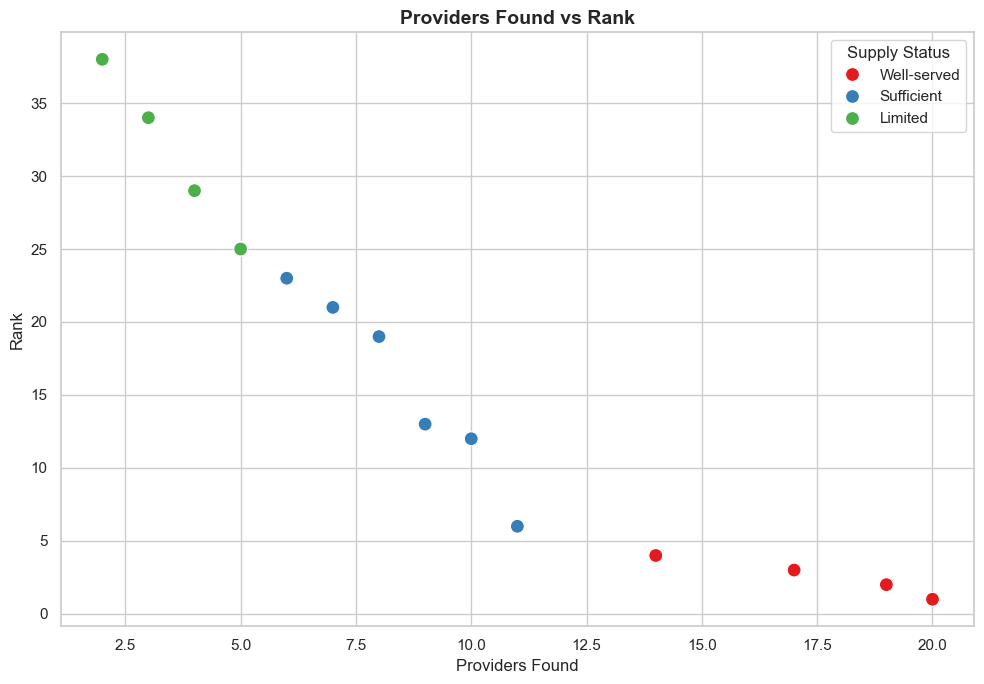

In [10]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="Provider Found", y="Rank", hue="Supply Status", palette="Set1", s=100)

plt.title("Providers Found vs Rank", fontsize=14, fontweight="bold")
plt.xlabel("Providers Found", fontsize=12)
plt.ylabel("Rank", fontsize=12)
plt.legend(title="Supply Status")

plt.tight_layout()
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()